# Do Discounts Affect Customer Ratings?

**Experiment Design & Observational Analysis**  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Author:** Joe Laniado  
**Date:** June 2026

## 1. Executive Summary
This project looks at whether discounted purchases are associated with different customer ratings on Olist, a Brazilian e-commerce marketplace. I analyzed 31,004 eligible orders over 12 months and defined discounts relative to each seller-product pair’s observed pricing history. Because the historical discounts were not randomly assigned, the results are interpreted as associations rather than causal effects.

The primary analysis uses a seller-product and month fixed-effects regression, with standard errors clustered by seller-product pair. The estimated association between discount status and customer rating was $\beta = 0.008$ rating points with a 95% confidence interval of $[-0.057, 0.074]$ and $p = 0.804$. The entire confidence interval falls well within the pre-specified 0.3 rating-point threshold for practical importance. Unadjusted rank-based and dose-response analyses produced qualitatively consistent results.

**Business takeaway:** discounted purchases were not associated with meaningfully higher or lower customer ratings. Sellers can therefore use discounting without expecting a material change in ratings based on the historical evidence, although the observational design does not establish causality.

Because the historical analysis cannot establish causality, I also designed a randomized A/B test that could test the question directly. With 80% power, $\alpha = 0.05$, and a 0.3-point minimum detectable effect, the experiment would require about 274 observed ratings per group.



## 2. Business Problem & Experiment Context

### 2.1 Business Motivation
Discounts and promotions are among the most widely used tools in e-commerce. The whole concept stems from the assumption that a product's perceived value is anchored to its original price, so when a discount is applied, the customer may feel they are receiving that same value at a lower cost, creating a sense of opportunity.

This raises an interesting question about customer psychology: **If a customer pays less than the listed price, does that alter how they evaluate the product after purchase?**

Two competing effects are plausible:
- **Leniency**: customers who received a discount may feel they got a good deal and be more lenient when rating the product, regardless of the product's actual quality.
- **Quality perception**:  a heavily discounted product may signal low demand or poor quality to the customer before purchase, priming them to evaluate it more critically upon receipt.

If either effect is present and measurable, it has direct implications for how businesses develop their pricing strategies. **What if chasing short-term sales volume through discounting risks long-term damage to customer satisfaction?**


### 2.2 Research Question

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>Are discounted purchases associated with different customer ratings than purchases made at or near their historical reference price?</b>
</div>


### 2.3 Experimental vs Observational Setting
The historical Olist data were not collected through a randomized experiment. Therefore, the historical analysis can estimate associations between discount status and customer ratings, but it cannot establish that discounts causally change ratings.

Section 5 presents how the same business question could be tested causally using a prospective randomized A/B experiment.

### 2.4 Scope of Analysis
The historical analysis is limited to:

- Olist, a Brazilian e-commerce marketplace.
- Purchases from August 1, 2017 - July 31, 2018.
- Single-Item, delivered orders.
- For seller-product pairs with at least three prior price observations.
- Purchases that received a customer rating.

The results should not be generalized beyond this scope, as other markets, time periods, or types of purchases may behave differently.

## 3. Hypothesis & Statistical Framework

### 3.1 Primary Hypothesis
**Primary Test: Discount vs Non-Discounted Orders.**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> After adjusting for seller-product and time effects, discounted purchases are not associated with a difference in mean customer rating relative to non-discounted purchases. ($\mathbf{\beta} = 0$)<br><br>
<b>H<sub>1</sub>:</b> After adjusting for seller-product and time effects, discounted purchases are associated with a difference in mean customer rating relative to non-discounted purchases. ($\mathbf{\beta} \neq 0$)
</div>

### 3.2 Primary Outcome Metric

**Customer rating** (1-5): The review score submitted by the customer on a 1-5 scale for a single item purchase. If multiple reviews exist for one order, the earliest review is retained. To maintain one observation per customer, only each customer's first eligible delivered order within the analysis window is retained.

### 3.3 Treatment & Control Groups
- **Control:** Orders priced less than 1% below their seller-product prior maximum observed price. It represents orders near, equal to, or above their historical reference price.
- **Treatment:** Orders priced at least 1% below their seller-product prior maximum observed price. It represents orders with an inferred discount from their historical reference price.

### 3.4 Primary Estimand
The primary estimand is the adjusted mean difference in customer rating associated with discounted versus non-discounted purchases within the eligible analytical population.

An absolute difference of 0.3 rating points is pre-specified as the smallest effect considered practically meaningful.


### 3.5 Statistical Parameters
The statistical parameters for each section of our analysis are as follows:

**Historical Observational Analysis**:
- Significance level: $\alpha$ = 0.05
- Practical absolute difference threshold: $|\Delta|$ = 0.3 rating points.

**Prospective A/B Test design**
- $\alpha$ = 0.05
- *Power* = 0.80
- *MDE* = 0.3 rating points

### 3.6 Analysis Hierarchy
The analysis hierarchy follows a four-step approach:
- **Primary Test**: A fixed-effects linear regression estimating the adjusted association between discount status and mean customer rating, accounting for seller-product and time effects.
- **Sensitivity**: A Mann-Whitney U test provides an unadjusted rank-based comparison of customer ratings between discounted and non-discounted purchases, addressing the ordinal and skewed distribution. The effect size is calculated using rank-biserial correlation.
- **Exploratory**: A dose-response analysis uses Kruskal-Wallis to test whether rating distributions differ across discount depth groups. The effect size is calculated using epsilon-squared ($\epsilon^2$).
- **Experiment Design**: A prospective randomized A/B Test Design demonstrates randomization, sample size planning, Type I error, statistical power, and the operating characteristics of the proposed experiment.

## 4. Historical Data

### 4.1 Data Overview

The raw historical data is sourced from a Brazilian e-commerce public dataset of orders made at Olist Store between 2016 and 2018. The entire history is loaded into a DuckDB database and run through a pre-processing pipeline using SQL to prepare for the analytical dataset. The complete ETL process can be found at **ETL.ipynb**.

The clean analytical table contains 31,004 rows presented at the order level for the period of **August 1, 2017 - July 31, 2018**.  Each order corresponds to a unique customer, has one retained review and one product, and belongs to a seller-product pair with at least three prior price observations.

In [1]:
import numpy as np
import pandas as pd
np.random.seed(42)

# Loading the data.
path = "data/clean_sales_data.csv"
df = pd.read_csv(path)

# Modify data type of date variable.
df = df.astype({'order_purchase_timestamp':'datetime64[ns]'})

#df.info()

# Output 
print(f"Total rows: {len(df):,}\n"
    f"Unique orders: {df['order_id'].nunique():,}\n"
    f"Unique customers: {df['customer_unique_id'].nunique():,}")

Total rows: 31,004
Unique orders: 31,004
Unique customers: 31,004


The clean data has no missing values and the total number of rows is equal to unique orders.

### 4.2 Group Distribution
There is an unequal number of discounted and non-discounted orders. The distribution across the control and treatment groups can be seen below:

In [2]:
# Separate discounted orders.
df['discounted'] = np.where(df['discount_ptg']>=1, 1, 0)

control, treatment = df[df['discounted']==0], df[df['discounted']==1]

print(f"Total orders in dataset: {len(df):,}\n"
      f"Orders in Control: {len(control):,}\n"
      f"Orders in Treatment: {len(treatment):,}")

Total orders in dataset: 31,004
Orders in Control: 20,828
Orders in Treatment: 10,176


The analytical cohort contains 20,828 non-discounted orders (67.2%) and 10,176 discounted orders (32.8%). Although the groups are unequal in size, both contain substantial numbers of observations, so no artificial balancing or downsampling is required.

### 4.3 Primary Metric Distribution
Ratings are strongly concentrated at five stars, producing a negatively skewed distribution.  We visualize the distribution of our variable and separate it by their assigned group below:

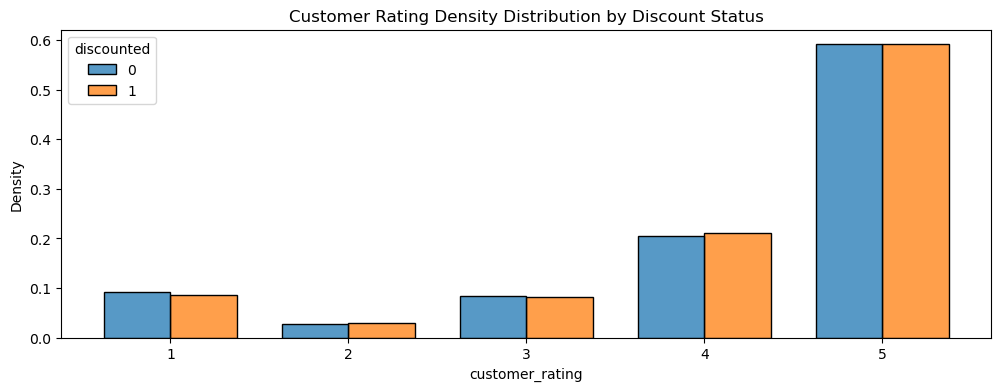

Mean and standard deviation for our analytical dataset:
Population mean = 4.18, sd = 1.25
Control mean = 4.18, sd = 1.26
Treatment mean = 4.19, sd = 1.24



In [3]:
# Vizualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Customer_rating visualization.
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(data=df,x='customer_rating',
             hue='discounted',
             discrete=True,
             ax=ax,
             multiple='dodge',
             shrink=0.75,
             stat='density',
             common_norm=False)
ax.set_title("Customer Rating Density Distribution by Discount Status")
plt.show()

pop_mean, pop_sd = df['customer_rating'].mean(), df['customer_rating'].std()
control_mean, treatment_mean = control['customer_rating'].mean(), treatment['customer_rating'].mean()
control_sd, treatment_sd = control['customer_rating'].std(), treatment['customer_rating'].std()

print(f"Mean and standard deviation for our analytical dataset:\n"
      f"Population mean = {pop_mean:.2f}, sd = {pop_sd:.2f}\n"
      f"Control mean = {control_mean:.2f}, sd = {control_sd:.2f}\n"
      f"Treatment mean = {treatment_mean:.2f}, sd = {treatment_sd:.2f}\n")

The raw mean ratings are nearly identical between groups: 4.18 for non-discounted orders and 4.19 for discounted orders. This comparison is descriptive and unadjusted, so no inferential conclusion is drawn at this stage.

### 4.4 Treatment Variable
The original dataset does not contain an explicit discount indicator, so it had to be engineered from the raw dataset. **Discount_ptg** was calculated using the following formula:

$$\text{Discount \%(t)} = max\left(0,\frac{P_{max\_prior} - P_{t}}{P_{max\_prior}}\times 100\right) $$

where $P_{max\_prior} $ represents the seller-product's prior maximum observed price. Positive values represent the percentage reduction from the seller-product's prior maximum observed price; purchases at or above that historical reference price are assigned a discount depth of 0%.

This proxy requires sufficient historical pricing information. Orders with fewer than three prior seller-product price observations are therefore excluded from the analytical cohort rather than automatically classified as non-discounted.

The distribution for **discount_ptg** can be seen below:

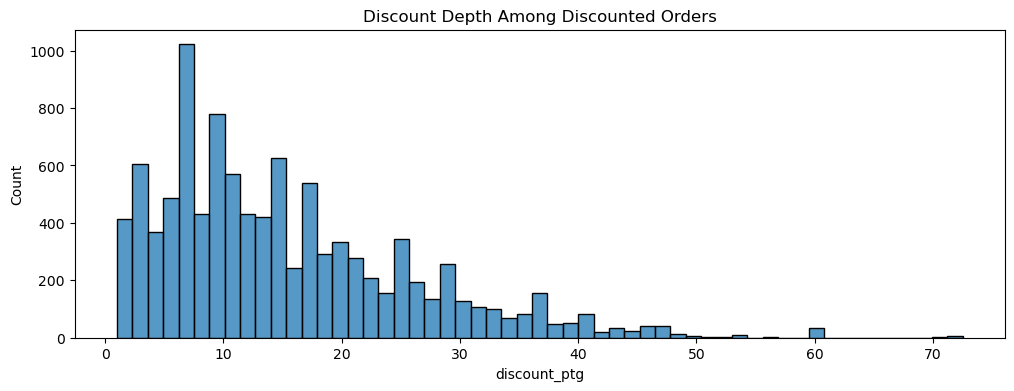

In [4]:
# Discount_ptg
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(data=df[df['discounted']==True],
             x='discount_ptg',
             ax=ax,
             )
ax.set_title("Discount Depth Among Discounted Orders")
plt.show()

Most discounts seem to fall on the low to medium range, with only a few on the deeper end. 

### 4.5 Discounts Over Time

We explore discounting over time by plotting the percentage of orders with a discount by month throughout the year. This helps us identify any effect that time and seasonality could have in our results.

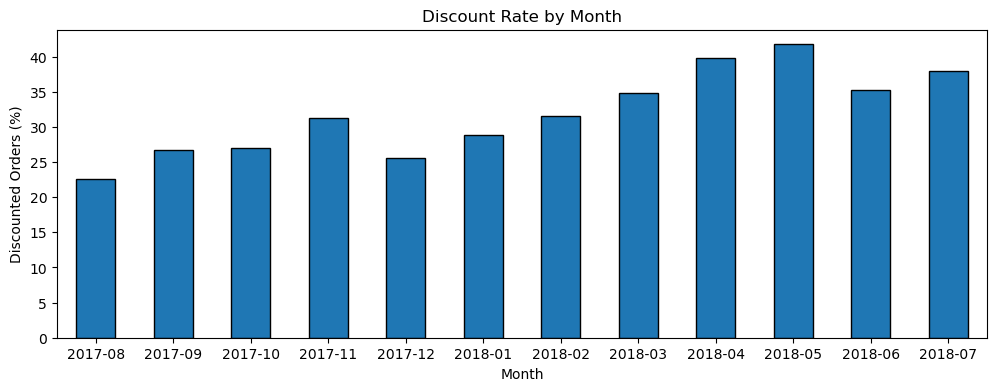

In [5]:
df["month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Plot discount variation by month
fig, ax = plt.subplots(figsize=(12, 4))

monthly_discount = (
    df.groupby("month")["discounted"]
      .mean()
      .mul(100)).plot(kind='bar', ax=ax, edgecolor='black')

ax.set_title('Discount Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Discounted Orders (%)')
plt.xticks(rotation=0, ha='center')
plt.show()

The percentage of discount orders seem to lean towards more discounts in the spring and summer while tapering down during fall and winter. This temporal variation supports the inclusion of month fixed effects in the primary adjusted model.

### 4.6 Seller-Product Treatment Variation

Because the primary fixed-effects model relies on within seller-product variation in discount status, we examine how many seller-product pairs are observed under both discounted and non-discounted conditions.

In [6]:
# Create seller-product variable
df["seller_product_id"] = (df["seller_id"] + "_" + df["product_id"])

# Calculate the treatment variation by seller-product
pair_variation = df.groupby("seller_product_id")["discounted"].agg(["count", "nunique", "mean"])
number_pairs = len(pair_variation)

# Calculate distribution of pairs by group
only_control = ((pair_variation['nunique'] == 1) & (pair_variation['mean']==0)).sum()
only_treatment = ((pair_variation['nunique'] == 1) & (pair_variation['mean']==1)).sum()
both = (pair_variation['nunique']==2).sum()

mixed_ids = pair_variation.query("nunique == 2").index

n_obs_mixed = df["seller_product_id"].isin(mixed_ids).sum()

print(f"Out of a {number_pairs:,} unique seller-product pairs:\n\n"
    f"{only_control:,} appear only in the control group\n"
    f"{only_treatment} appear only in the treatment group\n"
    f"{both} appear in both\n\n"
    f"{n_obs_mixed:,}/{len(df):,} of our observations have a seller-product pair that appears in both groups.")


Out of a 4,539 unique seller-product pairs:

3,250 appear only in the control group
712 appear only in the treatment group
577 appear in both

10,746/31,004 of our observations have a seller-product pair that appears in both groups.


Of the 4,539 unique seller-product pairs, 577 (12.7%) appear under both discounted and non-discounted conditions. These mixed pairs account for 10,746 orders (34.3% of the analytical dataset). Because seller-product fixed effects estimate the discount association using within-pair variation, these observations provide the primary identifying variation for the adjusted model. The number of mixed pairs and observations indicates that a within seller-product analysis is feasible.

## 5. Prospective A/B Test Design

### 5.1 Experiment Design
The experimental unit would be the **customer**, and our group definition would be similar to that used in our observational analysis:
- **Control**: Customers assigned to the standard pricing experience.
- **Treatment**: Customers assigned a predefined discount offer.
  
Once randomized, customers remain in their assigned condition for the duration of the experiment to prevent crossover between treatment and control. Eligible customers will be randomly assigned 50/50 to treatment or control.

Our primary metric remains **customer rating** on the 1-5 scale and we define our hypothesis as follows:

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> There is no difference between the mean rating of control and our treatment group: $\mu_t - \mu_c = 0$<br>
<b>H<sub>1</sub>:</b> There is a difference between the mean rating of control and our treatment group: $\mu_t - \mu_c \neq 0$
</div>

### 5.2 Statistical Design
As mentioned in section 3.5, our experiment would be done with the following parameters:
- $\alpha$ = 0.05
- *Power* = 0.8
- *MDE* = 0.3 rating points

Using these parameters and the standard deviation of past observed customer ratings ($sd = 1.25$) as a reference, we perform a power analysis to determine the required sample size for each group.

In [7]:
from statsmodels.stats.power import TTestIndPower
# Experiment key components
significance = 0.05
power = 0.8
mde = 0.3

cohens_d = mde / pop_sd

# Declare power analysis 
analysis = TTestIndPower()
sample_size = int(np.ceil(analysis.solve_power(effect_size=cohens_d, 
                                               alpha=significance, 
                                               power=power,
                                               ratio=1.0,
                                               alternative="two-sided")))

print(f'The minimum number of samples per group to spot a real effect given our parameters is: {sample_size}')

The minimum number of samples per group to spot a real effect given our parameters is: 274


The power analysis requires approximately **274** observed customer rating outcomes per group, or 548 total. Because not every randomized customer will purchase and submit a review, the number of customers randomized would need to be larger. Historical purchase and review rates could be used to estimate the historical expected probability of a customer leaving a review given they make a purchase to come up with a reference number on how many to include in our randomization process.

There is also the possibility that conversion could be affected by our treatment, as customers presented with a discount might be more inclined to make a purchase. Adding both conversion and review completion rates as secondary metrics to monitor might be useful when evaluating the validity of our groups. 

### 5.3 Experiment Validity & Stopping Rules
The experiment will be predefined with a specific sample size and duration cycle needed before completion. The sample size must be large enough for both groups to satisfy the minimum number of observed customer ratings for each group calculated in our power analysis, and the duration will run for at least one complete week cycle, with a predefined follow-up period for ratings to be submitted after purchase.

We will establish the following guardrail metrics to prevent the experiment from affecting normal operations of our e-commerce platform:
- Revenue per randomized customer.
- Conversion rate.
  
This will help monitor that discounts are not affecting revenue and that conversion does not suffer due to our treatment. Treatment allocation will be monitored for sample ratio mismatch as well, which could indicate an error in our process.

### 5.4 Simulation
We can simulate 10,000 experiments under the null hypothesis and visualize Type 1 errors and what statistical power represents. As a reminder, we defined the following parameters:
- Probability of a Type 1 error: $\alpha$ = 0.05
- Probability of detecting MDE if there is one: *Power* = 0.8
- Minimum detectable effect: *MDE* = 0.3 rating points
- Minimum required observed rating outcomes per group: *n* = 274

We simulate our control and treatment groups by drawing our minimum sample size (274) from a normal distribution with the same population mean and standard deviation ($\mu_p = 4.18, sd = 1.25$) we got from our historical dataset. Because no true treatment effect exists, the proportion of experiments producing $p<0.05$ estimates the Type I error rate. We used a normal distribution instead of a discrete 1-5 bounded approximation, as the intention is to illustrate the operating characteristics of our test and not to reproduce the exact historical rating distribution.

In [8]:
# Define random number generator
from scipy import stats

def simulate_experiment(effect, n_simulations=10000):
    rgn = np.random.default_rng(42)
    
    # Count the number of significant results
    sig_count = 0
    
    # Simulate 10,000 tests
    for _ in range(n_simulations):
        # Generate synthetic ratings for each group.
        control = rgn.normal(pop_mean,pop_sd,sample_size)
        treatment = rgn.normal(pop_mean+effect,pop_sd,sample_size)
    
        # Perform statistical test.
        t_stat, p = stats.ttest_ind(control,treatment,equal_var=False)
    
        # Count the number of significant results
        if p <=0.05:
            sig_count +=1
    return sig_count/n_simulations

In [9]:
# Call simulation with defined effect
result = simulate_experiment(effect=0)

print(f"\nGiven our experiment parameters and that there is no difference between the groups:\nWe would reject the null hypothesis "
    f"{(result)*100:.2f}% of the time.")


Given our experiment parameters and that there is no difference between the groups:
We would reject the null hypothesis 4.87% of the time.


The simulated Type I error rate is 4.87%, closely matching the pre-specified $\alpha=0.05$. This indicates that the testing procedure behaves as expected under the null hypothesis. 

We next introduce a true treatment effect equal to the pre-specified MDE of 0.3 rating points. The proportion of simulated experiments producing p<0.05 estimates the statistical power of the proposed design.

In [10]:
# Call simulation with defined effect
result = simulate_experiment(effect=mde)

print(f"\nGiven our experiment parameters and a difference of 0.3 rating points in the group means:\n"
      f"We detect a significant effect {(result)*100:.2f}% of the time.")


Given our experiment parameters and a difference of 0.3 rating points in the group means:
We detect a significant effect 79.68% of the time.


The simulated power is 79.65%, closely matching the target of 80%. This confirms that approximately 274 observed ratings per group are sufficient to detect a true 0.3 point mean difference under the assumptions used in the power calculation.

### 5.5 Power Curve
Using our predefined experiment metrics, let's simulate a number of different true effect sizes and evaluate the results.

In [11]:
# Calculate Power by effect size
effects = [0,0.1,0.2,0.3,0.4,0.5,0.8,1]
powers = [simulate_experiment(effect=e) for e in effects]

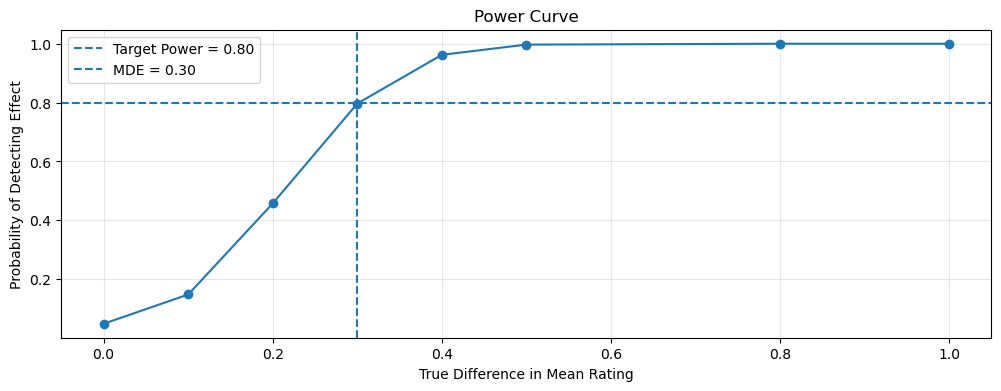

In [12]:
# Plot power curve
fig, ax = plt.subplots(figsize=(12,4))
plt.plot(effects,
         powers,
         marker = "o")
plt.axhline(
    0.8,
    linestyle="--",
    label="Target Power = 0.80"
)

plt.axvline(
    0.3,
    linestyle="--",
    label="MDE = 0.30"
)
plt.xlabel("True Difference in Mean Rating")
plt.ylabel("Probability of Detecting Effect")
plt.grid(alpha=0.3)
plt.title('Power Curve')
plt.legend()
plt.show()


As the true difference in mean rating increases the higher the probability of detecting the effect under our current experiment parameters. We see that with a 0.3 rating-point difference, our 80% power approximation is spot on.

## 6. Primary Historical Analysis

### 6.1 Fixed-effects Linear Regression
As discussed in Section 3.6, the primary historical analysis uses a fixed-effects linear regression to estimate the adjusted association between customer rating and discount status while accounting for seller-product and month effects. The equation of our model can be expressed as:

$$ \large Rating_{it} = \beta Discount + \alpha_i + \gamma_t + \epsilon_{it}$$

$\beta$ represents the average rating difference associated with discounted versus non-discounted purchases after accounting for seller-product and month fixed effects. $\alpha_i$ absorbs stable differences across seller-product pairs, $\large \gamma_t$ captures common month level differences, and $\large \epsilon_{it}$ represents the remaining unexplained variation.

### 6.2 Basic Checks
We select the variables required for the primary model and perform a final validation of the analytical dataset. Section 4 provides the detailed preparation and diagnostic checks for the full historical cohort.

In [13]:
print(f"Observations: {len(df):,}")
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Seller-product pairs: {df['seller_product_id'].nunique():,}")
print(f"Months: {df['month'].nunique():,}")

print("\nTreatment counts:")
print(df["discounted"].value_counts(),"\n")

primary_df = df[['customer_rating','discounted','seller_product_id','month']]
#primary_df.info()

Observations: 31,004
Unique orders: 31,004
Seller-product pairs: 4,539
Months: 12

Treatment counts:
discounted
0    20828
1    10176
Name: count, dtype: int64 



We have 31,004 distinct orders over 12 months. No missing values are present, and the distribution of discounted orders is 1/3 of our total. There are 4,539 unique seller-product pairs, with 577 appearing in both groups, which represent 10,746/31,004 of our observations. The other 3,962 pairs that appear in only one group do not provide any within group variation to estimate $\beta$, but may help estimate the fixed effect of time. Singleton seller-product observations that provide no usable within-pair information for estimation may be dropped automatically by our model.

### 6.3 Fitting our Model
We used the pyfixest package to build our fixed effects regression. We write our formula declaring *seller_product_id* and *month* as fixed effects to account for, and we specify for the variance-covariance matrix that the errors inside *seller_product_id* are not independent of each other and might be clustered.

In [14]:
# Import package
import pyfixest as pf
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*singleton fixed effect.*")

    # Build Fixed-effects ordinary least squares
    model = pf.feols("customer_rating ~ discounted | seller_product_id + month",
                     data=primary_df,
                     vcov={"CRV1": "seller_product_id"})
# Display summary
model.summary()

###

Estimation:  OLS
Dep. var.: customer_rating, Fixed effects: seller_product_id + month
sample: None = all
Inference:  CRV1
Observations:  29636

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| discounted    |      0.008 |        0.033 |     0.248 |      0.804 | -0.057 |   0.074 |
---
RMSE: 1.129 R2: 0.181 R2 Within: 0.0 


We present the following results:
- $\beta = 0.008$
- $SE = 0.033$
- $95\%$  $CI = [-0.057, 0.074]$
- $p-value = 0.804$
- $N = 29,636$

Our primary analysis is consistent with the descriptive pattern observed in Section 4.3. We found no evidence of an adjusted association between discount status and customer rating. Our estimated β = 0.008 indicates that, after accounting for seller-product and month fixed effects, discounted purchases were associated with ratings approximately 0.008 points higher on average, an almost negligible estimated association.

In addition to finding no statistically detectable association, the entire 95% confidence interval lies within our practically significant threshold of 0.3 rating points.

$$\large 95\% CI = [-0.057,0.074] $$
$$\large Practical Effect = [-0.3,0.3] $$

With these results and a p-value of 0.804, **we fail to reject the null hypothesis that $\beta=0$** as $p > 0.05$, our predefined $\alpha$, and 0 lies well within the 95% confidence interval.

In [15]:
pair_sizes = df.groupby("seller_product_id").size()

print("Singleton seller-product pairs:", (pair_sizes == 1).sum())

Singleton seller-product pairs: 1368


It is important to note the model removed 1,368 observations from the model bringing the total number of orders down to 29,636. This happened due a seller-product pair only having one appearance in our data, and not providing any variance on which to estimate the coefficient. 

## 7. Sensitivity Analysis 1: Difference in rank distribution.

### 7.1 Mann-Whitney U
As a sensitivity complement to our observational analysis, we perform a rank-based comparison between our control and treatment groups. This is to account for the left-skewed and ordinal distribution of customer ratings. We do this test on all of our eligible orders without any adjustments for seller-product pair or time variables. Essentially, presenting the question: **Across all eligible discounted and non-discounted orders, do ratings in one group tend to rank higher than the other?**

Our primary metric remains **customer rating** on the 1-5 scale, and we define our hypothesis as follows:

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> The distribution of customer ratings does not differ between groups.<br>
<b>H<sub>1</sub>:</b> The distribution of customer ratings is different between discounted and non-discounted orders.
</div>

We will report the effect size for our results as the rank-biserial correlation (r).

### 7.2 Running the Test

In [16]:
# Import test package
from scipy.stats import mannwhitneyu

control_rating, treatment_rating = control['customer_rating'], treatment['customer_rating']

# Run statistical test on unadjusted data.
stat, p_value = mannwhitneyu(control_rating,
                               treatment_rating,
                               alternative='two-sided',
                               method="asymptotic")

print(f'P-value of {p_value:.4f}\n')

if p_value < significance:
    print('We reject the Null Hypothesis: There is a significant difference between the two groups.')
else:
    print('We fail to reject Null Hypothesis: No significant difference between the two groups.')

# Effect size calculation
n1 = len(control)
n2 = len(treatment)
r  = 1 - (2 * stat) / (n1 * n2)

print(f"Effect size (rank-biserial r): {r:.4f}")

print(f"\nTreatment mean: {treatment_rating.mean():.3f}, "
    f"median: {treatment_rating.median():.1f}")

print(f"Control mean: {control_rating.mean():.3f}, "
    f"median: {control_rating.median():.1f}")

P-value of 0.5924

We fail to reject Null Hypothesis: No significant difference between the two groups.
Effect size (rank-biserial r): 0.0033

Treatment mean: 4.194, median: 5.0
Control mean: 4.177, median: 5.0


With a $p-value = 0.5924$ and an $r = 0.0033$, **we fail to reject the null hypothesis** and find no evidence of a difference in the unadjusted rating distributions between discounted and non-discounted orders. The effect size is very close to 0 and indicates essentially no rank separation between the groups. This is consistent with our primary analysis: neither analysis provides evidence of a meaningful difference in customer ratings associated with discount status.

## 8. Exploratory Analysis: Dose-Response Discount Buckets

### 8.1 Kruskal-Wallis Test
As a further exploratory measure, we will perform a dose-response analysis using Kruskal-Wallis to test whether rating distributions differ across discount depth groups. We group each order into 1 of 5 levels based on depth of discount:
- <1% Non-discounted group
- 1-10% Low discount
- 10-25% Medium discount
- 25-40% High discount
- 40%+ Very High discount

As a reminder, this does not override our primary test results, but could uncover insightful data that may warrant future experiments. Kruskal-Wallis determines whether a significant difference exists across groups. The null hypothesis is defined as follows:

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> The distribution of customer ratings is equal across all discount depth buckets.<br><br>
<b>H<sub>1</sub>:</b> At least one discount depth bucket has a different distribution in customer ratings compared to the others.
</div>

For this analysis, effect size will be measured using $\large \epsilon^2$. It measures the magnitude of rank-based separation across the discount groups. Values near zero indicate very little separation in the rank distribution between groups.

### 8.2 Descriptive Dose-Response
We assign orders to each discount bucket and calculate descriptive measures to ensure the data are ready for the test.

In [17]:
# Group discounts ranges into buckets.
labels = ["<1%","1–10%","10–25%","25–40%","40%+"]
df['discount_buckets'] = pd.cut(df['discount_ptg'], bins = [-np.inf,1,10,25,40,np.inf],right=False, labels=labels)

groups = []
for label in labels:
    groups.append(df.loc[df["discount_buckets"] == label, "customer_rating"])
    
bucket_summary = df.groupby("discount_buckets", observed=True)["customer_rating"].agg(N="size",mean="mean",median="median")

bucket_summary

,N,mean,median
discount_buckets,,,
<1%,20828,4.177021,5.0
1–10%,3784,4.216438,5.0
10–25%,4423,4.190369,5.0
25–40%,1655,4.146224,5.0
40%+,314,4.219745,5.0


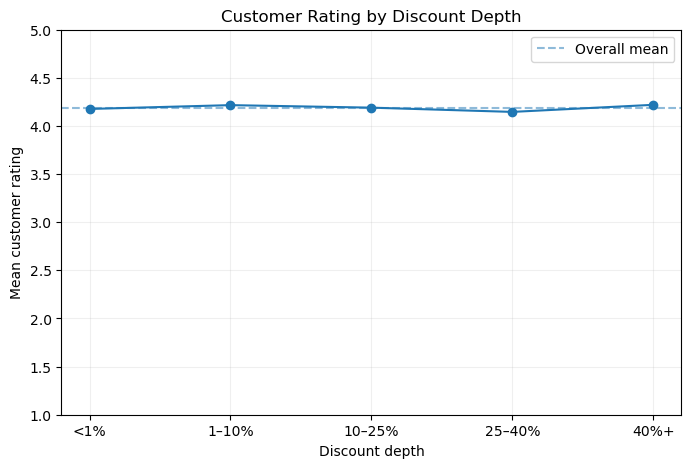

In [18]:

plot_data = df.groupby("discount_buckets", observed=True)["customer_rating"].mean()
plt.figure(figsize=(8, 5))
plt.plot(plot_data.index.astype(str),plot_data.values,marker="o")
plt.axhline(df["customer_rating"].mean(),linestyle="--",alpha=0.5,label="Overall mean")
plt.xlabel("Discount depth")
plt.ylabel("Mean customer rating")
plt.title("Customer Rating by Discount Depth")
plt.ylim(1, 5)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Our descriptive analysis shows very small variation in mean customer ratings across discount level groups. We'll use the Kruskal–Wallis test to assess whether there is statistical evidence that the rating distributions differ across groups, specifically whether at least one group differs from the others.

### 8.3 Kruskal-Wallis Test

In [19]:
# Import test package
from scipy.stats import kruskal

# Run Test on groups.
stat, p_value = kruskal(*groups)

# Epsilon squared equation
k = len(groups)
eps_sq = (stat-k+1) / (len(df) - k)

print(f'Our test statistic is: {stat:.2f} with a P-value of {p_value:.4f} and effect size of {eps_sq:.5f}\n')

if p_value < significance:
    print('We reject the Null Hypothesis: There is a significant difference between the five groups.')
else:
    print('We fail to reject Null Hypothesis: No significant difference between the five groups.')



Our test statistic is: 5.11 with a P-value of 0.2761 and effect size of 0.00004

We fail to reject Null Hypothesis: No significant difference between the five groups.


With a $p-value = 0.2761$ and an $\large \epsilon^2 = 0.00004$, **we fail to reject the null hypothesis** and find no evidence of a difference in the unadjusted rating distributions between groups at different discount levels. The separation in rating ranks across the discount bucket groups is almost non-existent given our small $\large \epsilon^2$.

## 9. Results Validation

### 9.1 FE Support & Clustering Structure
In this analysis, a cluster is defined as all the observations for a single seller-product pair. During the development of our model, 1,368 seller-product pairs were removed as they contained only one observation and therefore provided no within-pair variation for the fixed-effects estimation. We will validate this assertion and assess whether any single cluster accounts for an unusually large share of the estimation sample in our FE regression.

In [20]:
pair_count = df.groupby('seller_product_id').count()
single_count = pair_count[pair_count['order_id'] == 1]
multiple_count = pair_count[pair_count['order_id'] > 1]

print(f"The number of single seller-pair observations is: {single_count.shape[0]}.\n"
      f"The total number of seller-product pairs used in our model is {pair_count.shape[0]-single_count.shape[0]} "
      f"with {multiple_count['order_id'].sum()} observations.")

The number of single seller-pair observations is: 1368.
The total number of seller-product pairs used in our model is 3171 with 29636 observations.


We confirm that 1,368 seller-product pairs had only one observation, and after removing them, we are left with 29,636 orders, the same number that our model used in Section 6.3. As an extra validation measure, we visualize the number of observations by seller-product clusters as well.

count    3171.000000
mean        9.345948
std        18.071358
min         2.000000
25%         3.000000
50%         4.000000
75%         9.000000
max       330.000000
Name: order_id, dtype: float64


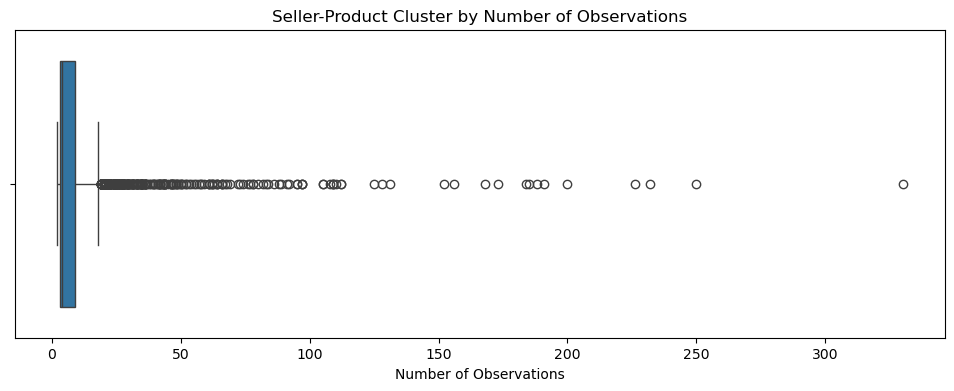

In [21]:
print(multiple_count['order_id'].describe())
fig, ax = plt.subplots(figsize=(12,4))
sns.boxplot(data=multiple_count,
            x='order_id',
            ax=ax)
ax.set_xlabel("Number of Observations")
ax.set_title("Seller-Product Cluster by Number of Observations")
plt.show()


The largest cluster contains 330 observations, approximately 1.1% of the 29,636 observation estimation sample. No individual seller-product pair therefore accounts for a large share of the estimation sample, reducing concern that the clustered inference is dominated by a single unusually large cluster.

### 9.2 Results Summary

In [22]:
robustness_summary = pd.DataFrame({"Analysis": 
                                   ["Primary fixed-effects regression",
                                    "Mann-Whitney sensitivity",
                                    "Dose-Response Kruskal-Wallis"],
                                   "Adjustment": 
                                   ["Seller-product + month FE",
                                    "Unadjusted",
                                    "Unadjusted"],
                                    "Effect / statistic": 
                                   ["β = 0.008",
                                    "Rank-biserial = 0.0033",
                                    "ε² ≈ 0.00004"],
                                    "p-value": [
                                    0.804,
                                    0.5924,
                                    0.2761],
                                    "Statistical evidence of difference?": 
                                   ["No",
                                    "No",
                                    "No"]})

robustness_summary

,Analysis,Adjustment,Effect / statistic,p-value,Statistical evidence of difference?
0,Primary fixed-effects regression,Seller-product + month FE,β = 0.008,0.8040,No
1,Mann-Whitney sensitivity,Unadjusted,Rank-biserial = 0.0033,0.5924,No
2,Dose-Response Kruskal-Wallis,Unadjusted,ε² ≈ 0.00004,0.2761,No


Although these analyses address different estimands and use different levels of adjustment, they provide qualitatively consistent evidence: **none detects a meaningful difference in customer ratings associated with discount status or discount depth.**

## 10. Conclusion & Business Recommendation

### 10.1 Overall Conclusion
The historical analysis found **no evidence that discounted purchases were associated with materially different customer ratings** after accounting for seller-product and month differences. The estimated association was very small ($\beta=0.008$), and its $95%$ confidence interval $[−0.057,0.074]$ remained well within the pre-specified 0.3 rating point threshold for practical importance. The unadjusted rank-based and dose-response analyses were qualitatively consistent with this conclusion.

### 10.2 Business Recommendation
**Recommendation**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>Discounts were not associated with meaningfully higher or lower customer ratings. Sellers can therefore use discounting without expecting a material change in customer ratings.</b>
</div>

Given that our analysis is based on observational historical data, we cannot establish that discounting causally affects customer ratings. If Olist requires stronger causal evidence, we recommend implementing the randomized A/B test outlined in Section 5 while also monitoring conversion and revenue.